In [1]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
posterior_NRSur7dq4 = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run1/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_sanity = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run1/sanity/outdir/final_result/sanity_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_dom_off = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run1/dom_off/outdir/final_result/dom_off_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_subdom_off = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run1/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json'
)

In [3]:
truths = posterior_NRSur7dq4.injection_parameters

truths

{'total_mass': 70.0,
 'mass_ratio': 0.667,
 'a_1': 0.8,
 'a_2': 0.5,
 'tilt_1': 1.5707963267948966,
 'tilt_2': 1.5707963267948966,
 'phi_12': 0.03163042414374728,
 'phi_jl': 3.399246630035568,
 'luminosity_distance': 680.0,
 'dec': 0.1,
 'ra': 0.1,
 'theta_jn': 0.341522468089182,
 'psi': 1.0471975512,
 'phase': 0.0,
 'geocent_time': 10.0,
 'reference_frequency': 20.0,
 'waveform_approximant': 'NRSur7dq4',
 'minimum_frequency': 20,
 'mass_1': 41.991601679664065,
 'mass_2': 28.00839832033593,
 'chirp_mass': 29.733827706714365,
 'symmetric_mass_ratio': 0.24002398080671805,
 'iota': array(0.55501061),
 'spin_1x': array(0.49601302),
 'spin_1y': array(0.62767116),
 'spin_1z': array(4.4408921e-17),
 'spin_2x': array(0.2974467),
 'spin_2y': array(0.4019023),
 'spin_2z': array(2.77555756e-17),
 'phi_1': 0.9020328836591283,
 'phi_2': 0.9336633078028758,
 'chi_eff': 3.7745584835411374e-17,
 'chi_1_in_plane': 0.8000000000000003,
 'chi_2_in_plane': 0.5,
 'chi_p': 0.8000000000000003,
 'cos_tilt_1': 

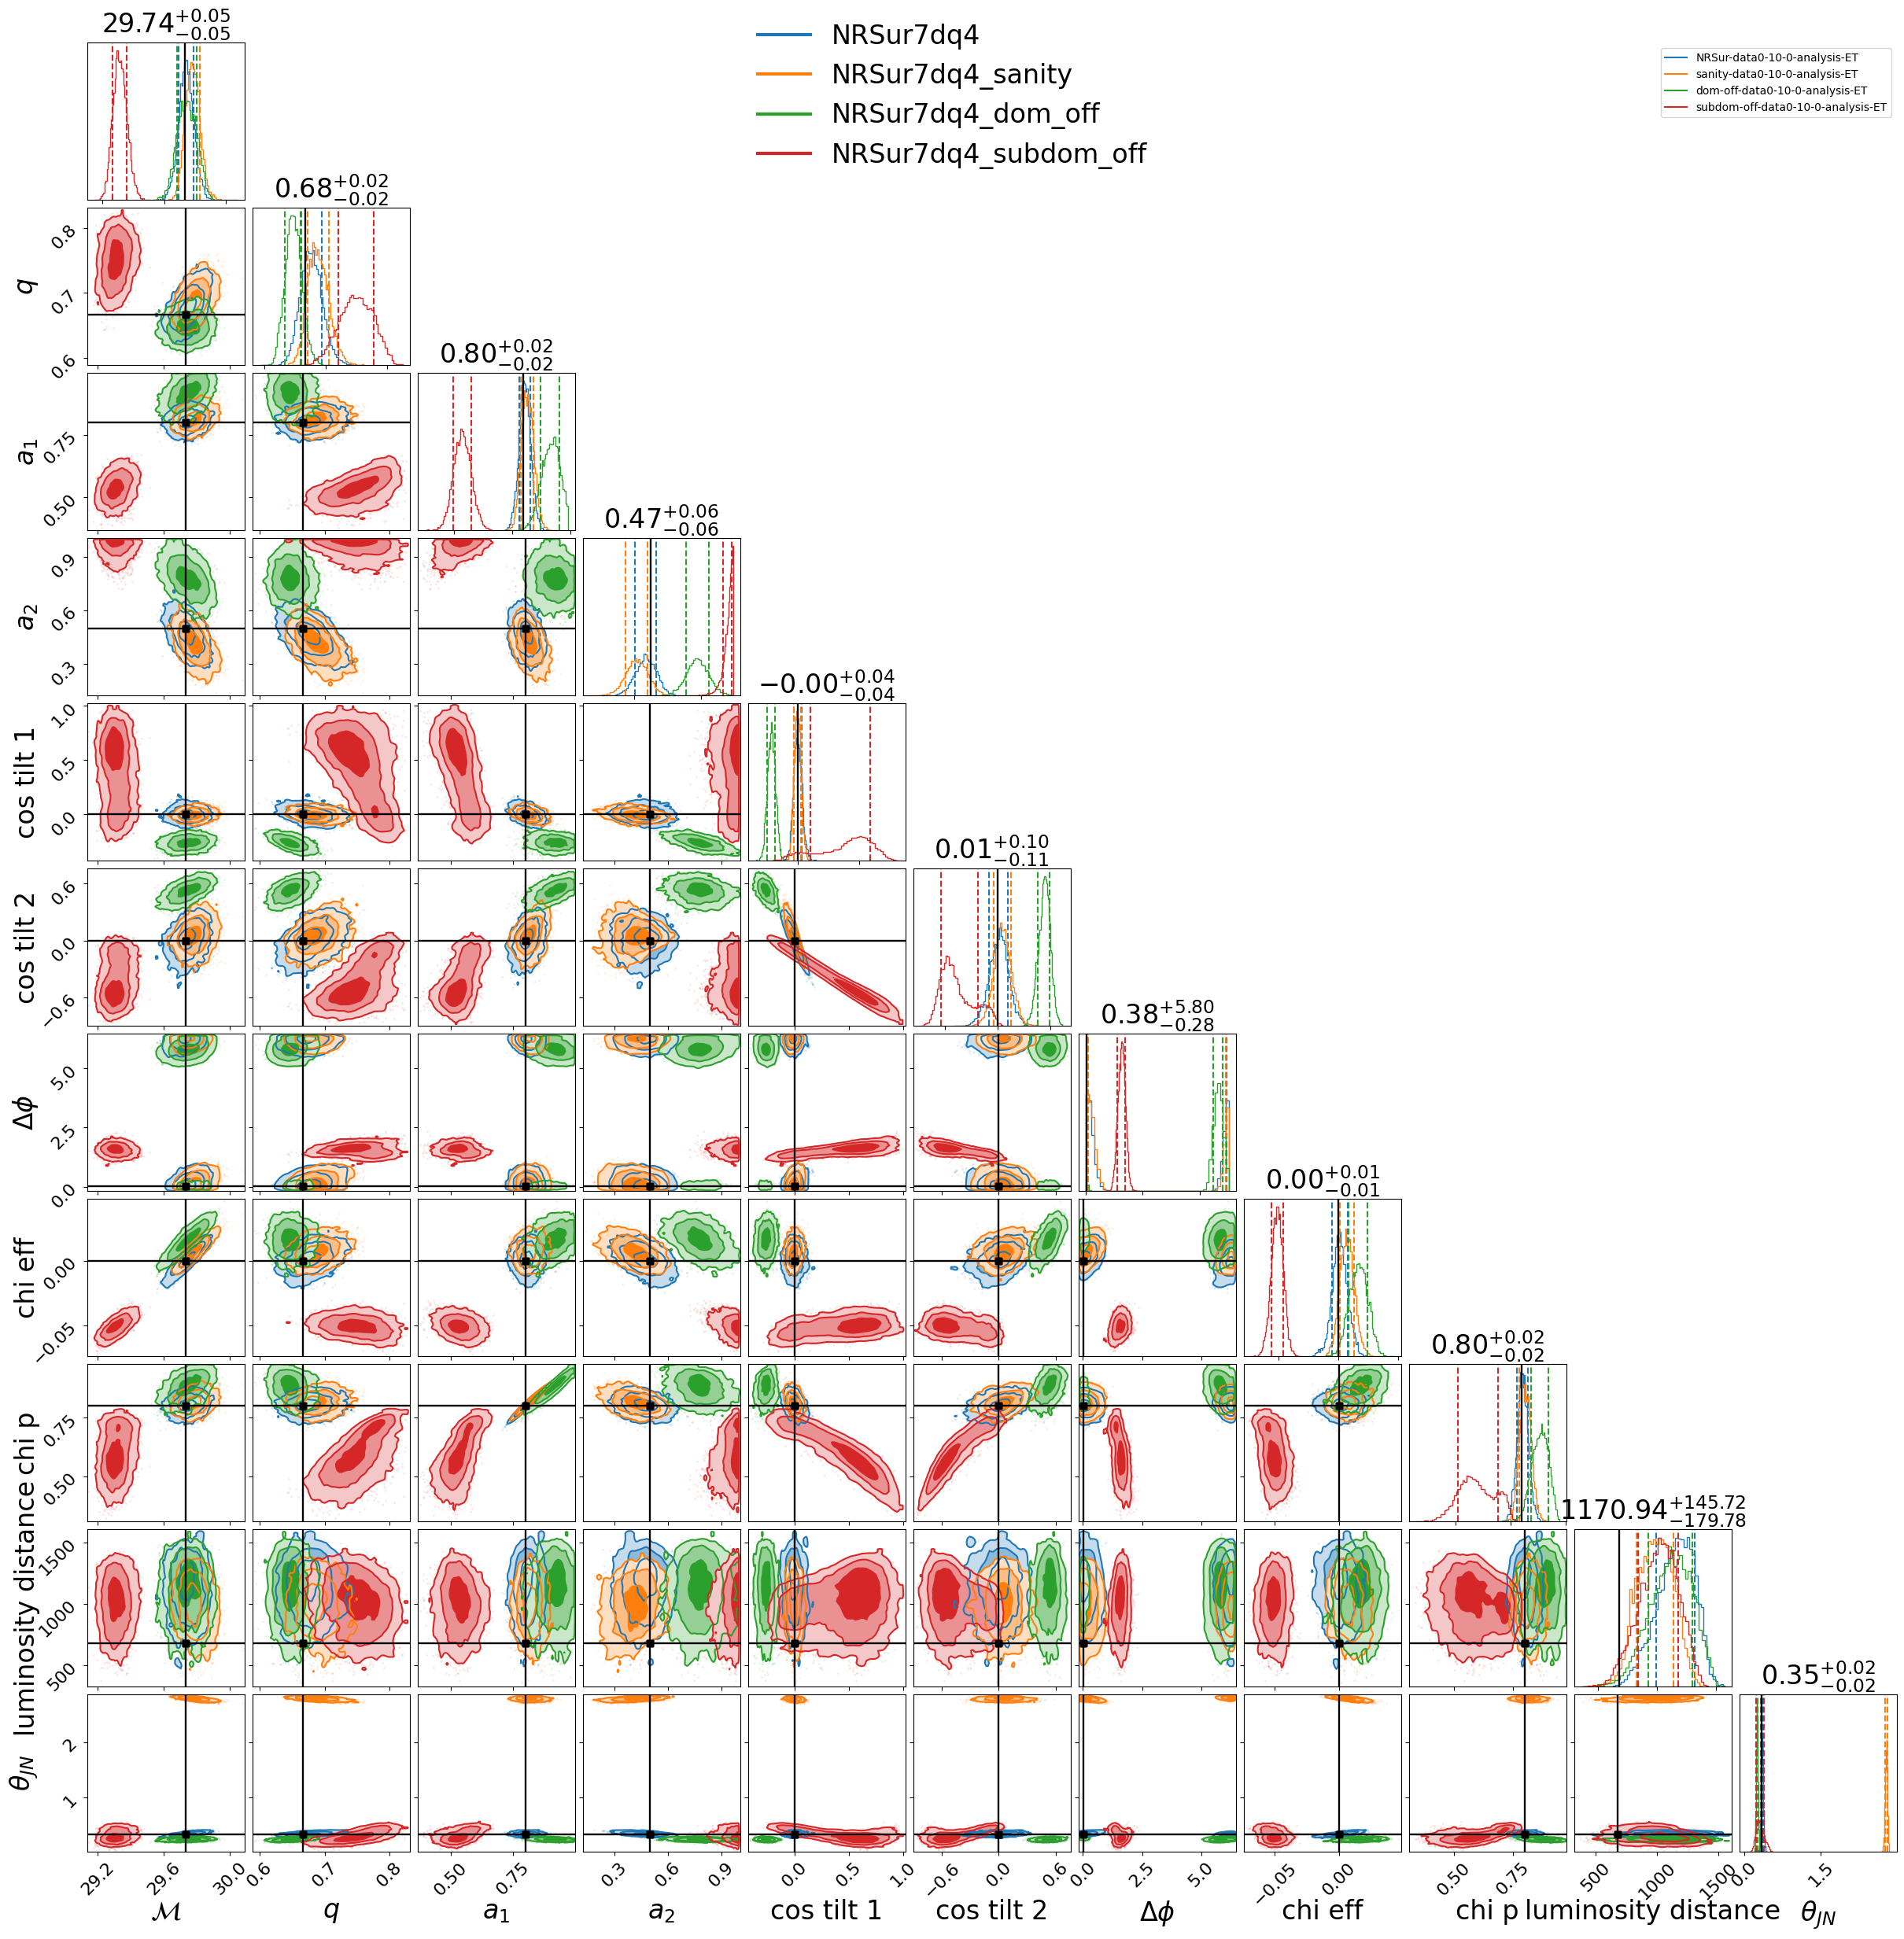

In [4]:
fig = bilby.result.plot_multiple(
    [
        posterior_NRSur7dq4,
        posterior_NRSur7dq4_sanity,
        posterior_NRSur7dq4_dom_off,
        posterior_NRSur7dq4_subdom_off
    ],
    filename=None, 
    parameters={
        'chirp_mass': truths['chirp_mass'],
        'mass_ratio': truths['mass_ratio'],
        'a_1': truths['a_1'],
        'a_2': truths['a_2'],
        'cos_tilt_1': np.cos(truths['tilt_1']),
        'cos_tilt_2': np.cos(truths['tilt_2']),
        'phi_12': truths['phi_12'],
        'chi_eff': truths['chi_eff'],
        'chi_p': truths['chi_p'],
        'luminosity_distance': truths['luminosity_distance'],
        'theta_jn': truths['theta_jn'],
    },
    colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'],
    smooth=True,
    title_kwargs=dict(fontsize=24),
    label_kwargs=dict(fontsize=24),
    truth_color='black'
)

# tick font size
for ax in fig.axes:
    ax.tick_params(labelsize=16) 


# legend
handles = [
    Line2D([], [], color='tab:blue', lw=3, label='NRSur7dq4'),
    Line2D([], [], color='tab:orange', lw=3, label='NRSur7dq4_sanity'),
    Line2D([], [], color='tab:green', lw=3, label='NRSur7dq4_dom_off'),
    Line2D([], [], color='tab:red', lw=3, label='NRSur7dq4_subdom_off')]
fig.legend(
    handles=handles,
    fontsize=24,
    loc='upper center',
    frameon=False)

fig.savefig('corner_comparison_run1.pdf', bbox_inches='tight')
plt.show()
